In questo notebook voglio calcolare per diversi tempi di osservazioni il coefficiente di trasmissione dello strumento per verificare che sia costante

In [10]:
import pickle

import matplotlib.pyplot as plt
import healpy as hp
import numpy as np

from pysimulators.interfaces.healpy import HealpixConvolutionGaussianOperator

In [16]:
data = pickle.load(open("/home/mattia/qubic/qubic/scripts/MapMaking/src/FMM/noise_eta_test/maps/test100days_None.pkl", "rb"))
# choose between test7days, test30days, test100days, test200days, test365days

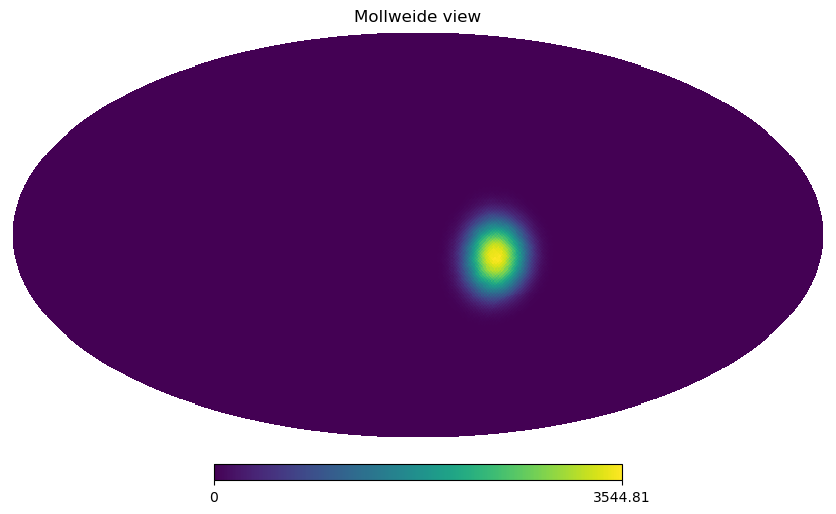

In [18]:
hp.mollview(data['coverage'])

In [19]:
fwhm_in = data["fwhm_in"]
fwhm_out = data["fwhm_out"]
fwhm_rec = data["fwhm_rec"]
# fwhm_rec[0] = 0.0061
# fwhm_rec[1] = 0.0041

nus = data["nus"]
Nrec = nus.shape[0] - 7

maps_input = data["maps_in_convolved"]
# for irec in range(Nrec):
#     C = HealpixConvolutionGaussianOperator(fwhm_rec[irec])
#     maps_input[irec] = C(maps_input[irec])
maps_rec = data["maps"][:Nrec]
maps_res = maps_input - maps_rec
center = data["center"]
seenpix = data["seenpix"]
convergence = data["convergence"]

In [20]:
print(Nrec)
print(nus.shape)
print(maps_input.shape)

1
(8,)
(1, 49152, 3)


In [21]:
print("FWHM in: ", fwhm_in)
print("mean fwhm in: ", np.mean(fwhm_in))
print("FWHM out: ", fwhm_out)
print("FWHM rec: ", fwhm_rec)

FWHM in:  [0.00770965 0.00747123 0.00724017 0.00701626 0.00679928 0.006589
 0.00638523 0.00618776]
mean fwhm in:  0.0069248230136742155
FWHM out:  [0.00459896 0.00418698 0.00375921 0.0033075  0.00281812 0.00226419
 0.00157569 0.        ]
FWHM rec:  [0.00618776 0.0093666  0.00785398 0.00383972 0.00279253 0.0020944
 0.00142535 0.00142535]


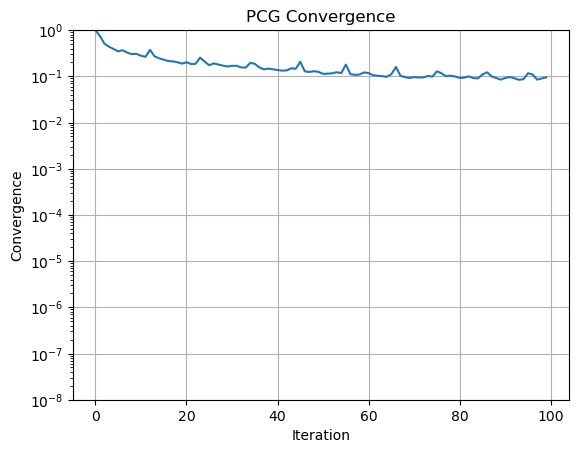

In [22]:
plt.plot(convergence)
plt.xlabel("Iteration")
plt.ylabel("Convergence")
plt.title("PCG Convergence")
plt.yscale("log")
plt.ylim(1e-8, 1e0)
plt.grid()
plt.show()

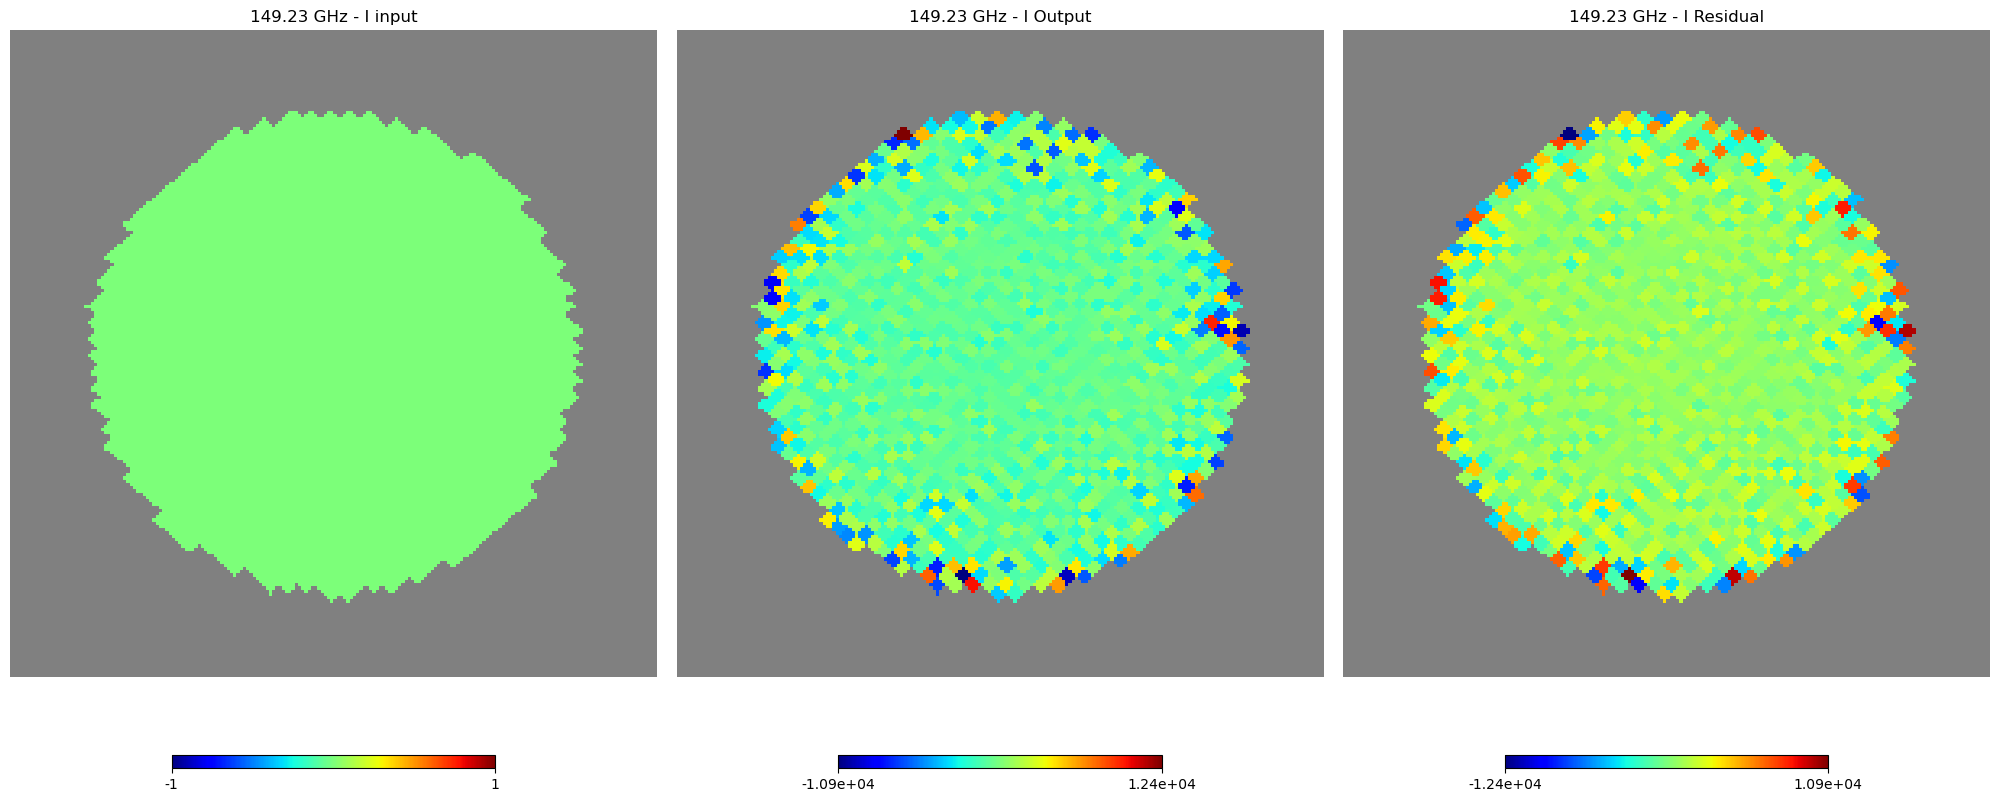

In [23]:
STOKES = ["I", "Q", "U"]

maps_input[:, ~seenpix, :] = hp.UNSEEN
maps_rec[:, ~seenpix, :] = hp.UNSEEN
maps_res[:, ~seenpix, :] = hp.UNSEEN

istk = 0
n = 2
# sigma_input = np.std(maps_input[:, seenpix, istk], axis=0)
# sigma_rec = np.std(maps_rec[:, seenpix, istk], axis=0)
# sigma_res = np.std(maps_rec[:, seenpix, istk] - maps_input[:, seenpix, istk], axis=0)

reso = 15

k = 0

plt.figure(figsize=(20, 10))
for inu in range(Nrec):
    hp.gnomview((maps_input[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} input",  
                        cmap="jet",
                        # min = - n * sigma_input[inu],
                        # max = n * sigma_input[inu],
                        sub=(Nrec, 3, k + 1))
    
    hp.gnomview((maps_rec[inu, :, istk]), rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Output",
                        cmap="jet",
                        # min = - n * sigma_rec[inu],
                        # max = n * sigma_rec[inu],
                        sub=(Nrec, 3, k + 2))
    
    hp.gnomview(maps_res[inu, :, istk], rot=center,
                        reso=reso,
                        notext=True,
                        title=f"{nus[inu].round(2)} GHz - {STOKES[istk]} Residual",
                        cmap="jet",
                        # min = - n * sigma_res[inu],
                        # max = n * sigma_res[inu],
                        sub=(Nrec, 3, k + 3))
    k += 3

In [24]:
noise_std = np.std(maps_rec[0,:,0][maps_rec[0,:,0]!=-1.6375e+30])
noise_std

2015.0030372909057

In [11]:
noise365_FI = noise_std

In [25]:
def calculate_eta(noise_std, days):
    nep = 2e-16
    fsky = 0.01
    omega_patch = 4*np.pi*fsky
    k_b = 1.38e-23
    delta_n = 40e9
    theta_pixel = 1/180*np.pi
    t_obs = days * 24 * 60 * 60
    N_det = 248

    return nep * np.sqrt(omega_patch) / (2*k_b*delta_n*theta_pixel * noise_std*1e-6 * np.sqrt(2*t_obs*N_det)) 

In [26]:
eta100_new = calculate_eta(636.6122818171646, 100)

In [90]:
eta7

2.7894406970922217e-05

In [91]:
eta30

2.7894407140644496e-05

In [92]:
eta100

2.7894274611636254e-05

In [93]:
eta200

2.7894407098371697e-05

In [94]:
eta365

2.7894407110356895e-05

In [28]:
eta100_new

8.829086348292657e-05

In [14]:
eta365_FI

0.0021368900746225705

Il valore di eta è sempre lo stesso indipendenteente dal tempo di osservazione ed è circa un ordine di grandezza più piccolo rispetto a quello ottenuto da Elenia, ovvero 4.5e-4